# INPUT and define global VARs

In [1]:
import numpy as np
import torch
import torch.utils.benchmark as benchmark
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import wraps
from time import perf_counter
from collections import namedtuple

from ragdoll.utils import *
from ragdoll.visualisation import *
from ragdoll.benchmark import *
import ragdoll

# IREE version: candidate-20230815.614

# use DCMAKE_BUILD_TYPE=RelWithDebInfo or Debug and DIREE_ENABLE_ASSERTIONS=ON


RAGDOLL_ROOT="../.."
RAGDOLL_WORKSPACE="../../build"
RAGDOLL_WORKLOADS="../../workloads"
CASE_NAME="matmul"

# TODO: add tf bench, add jax bench

2024-03-17 13:54:18.979765: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


# Input: Matmul (M,K,N) => (1026, 2556, 1026)

In [2]:
!{RAGDOLL_WORKSPACE}/bin/ragdoll-opt \
    {RAGDOLL_WORKLOADS}/common/operators/{CASE_NAME}.mlir \
    --pass-pipeline="builtin.module(func.func( \
    tosa-to-linalg-named \
))" > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg
!cat {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg

module {
  func.func @matmul(%arg0: tensor<1026x2556xf32>, %arg1: tensor<2556x1026xf32>) -> tensor<1026x1026xf32> {
    %cst = arith.constant 0.000000e+00 : f32
    %0 = tensor.empty() : tensor<1026x1026xf32>
    %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    %2 = linalg.matmul ins(%arg0, %arg1 : tensor<1026x2556xf32>, tensor<2556x1026xf32>) outs(%1 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    return %2 : tensor<1026x1026xf32>
  }
}



## GPU

benchmarking pytorch on operator@matmul
benchmarking tensorflow on operator@matmul


2024-03-17 13:54:41.170100: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-03-17 13:54:41.170210: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2024-03-17 13:54:41.170337: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-03-17 13:54:41.170490: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:21:00.0 name: NVIDIA GeForce RTX 3070 computeCapability: 8.6
coreClock: 1.77GHz coreCount: 46 deviceMemorySize: 7.78GiB deviceMemoryBandwidth: 417.29GiB/s
2024-03-17 13:54:41.170508: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2024-03-17 13:54:41.171872: I tensorflow/stream_executor/platform/def

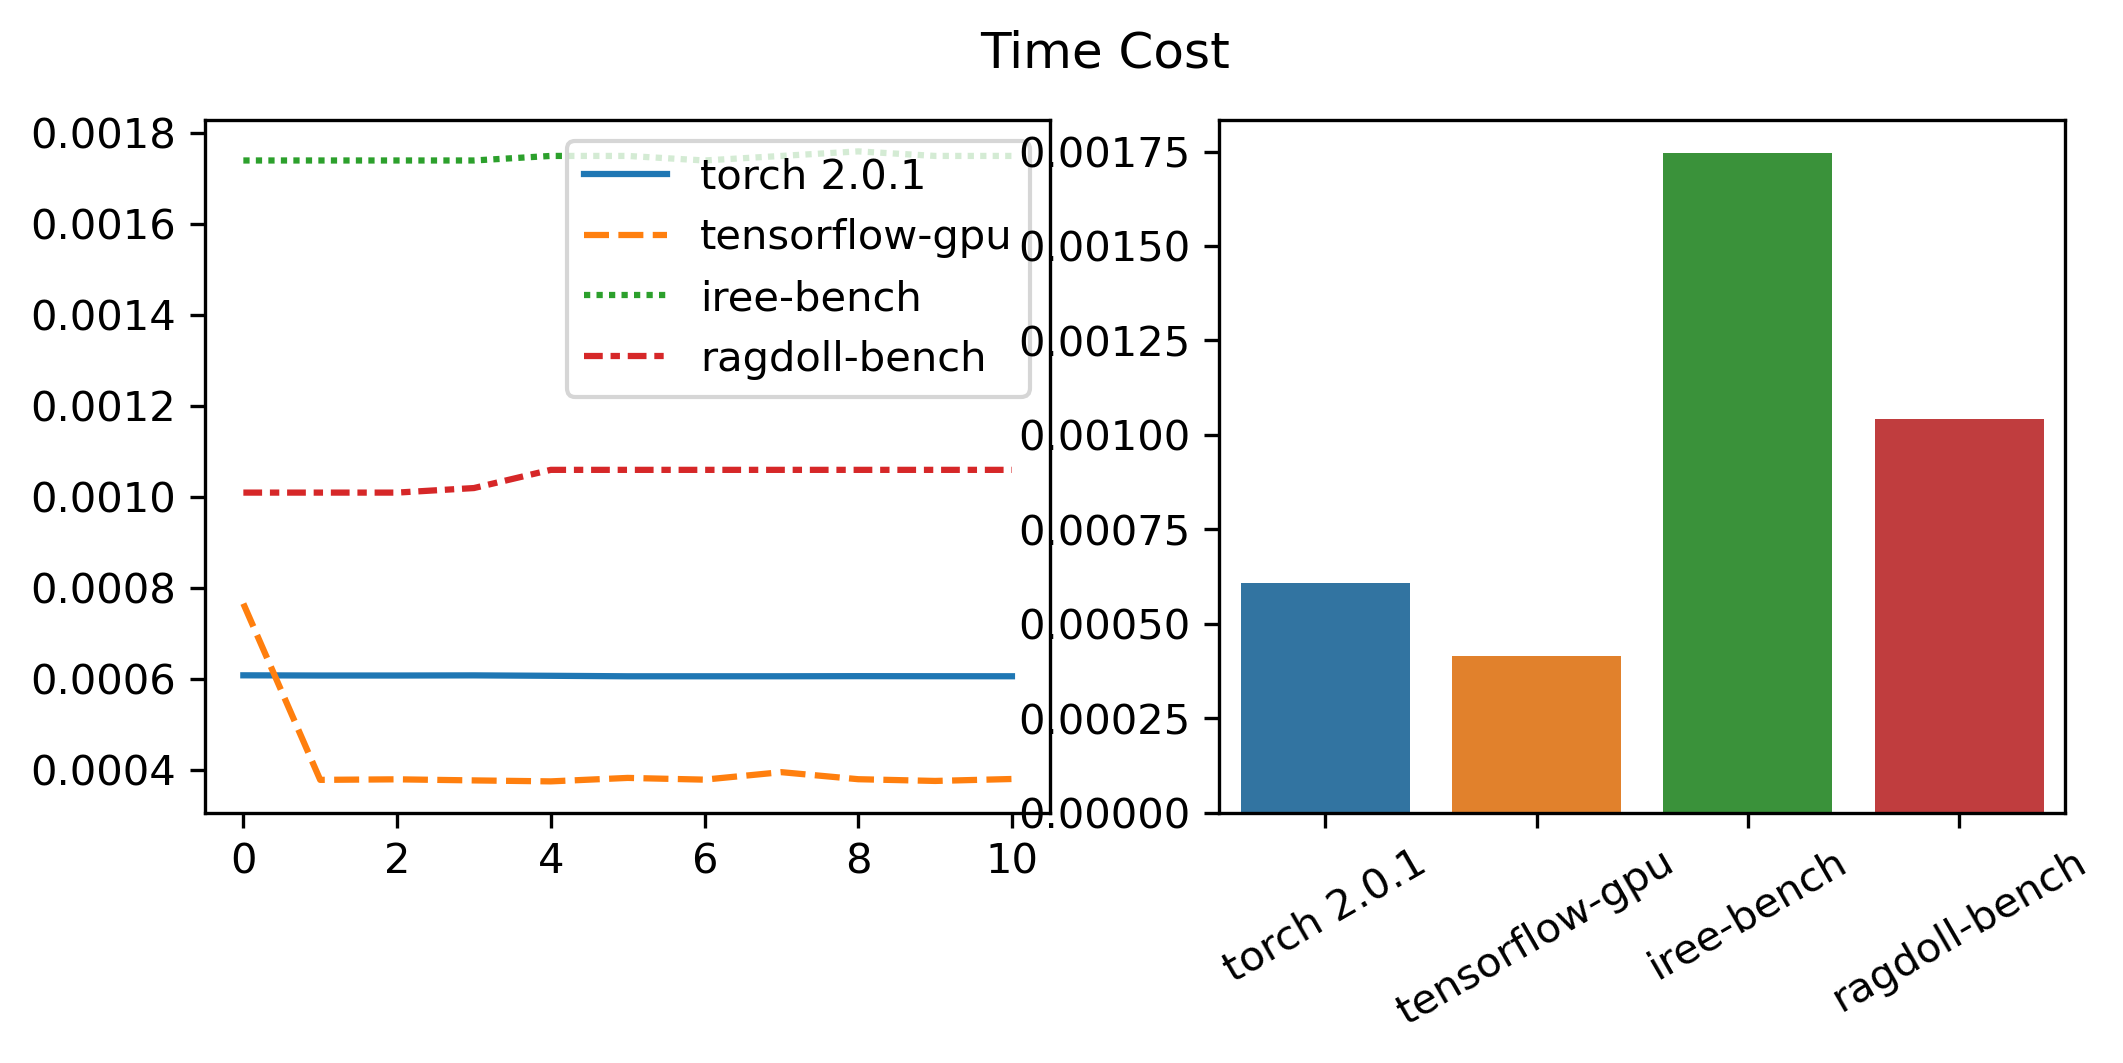

In [3]:
# release version
#!nohup iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
#-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.rel.vmfb \
#--iree-hal-target-backends=cuda \
#--iree-hal-cuda-llvm-target-arch=sm_70 > {RAGDOLL_WORKSPACE}/matmul.baseline.rel.dump 2>&1

compiled_baseline = ragdoll.compile(RAGDOLL_WORKSPACE+"/"+CASE_NAME+".mlir.linalg", "gpu", "input", "codegen", benchmark=True)
iree_bench = ragdoll_op_benchmark(
    compiled_baseline,
    [(1026, 2556), (2556, 1026)], 
    device='gpu',
    repetitions=17, 
    measure_count=11)

# benchmark version with repeatance
!nohup iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.bench.vmfb \
--mlir-print-ir-after-all \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count=17 \
--iree-hal-cuda-llvm-target-arch=sm_70 > {RAGDOLL_WORKSPACE}/matmul.baseline.bench.dump 2>&1

!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
--compile-from=input \
--compile-to=executable-sources \
--iree-hal-target-backends=cuda \
--iree-opt-const-eval=1 \
--iree-opt-const-expr-hoisting=1 \
--iree-opt-numeric-precision-reduction=1 \
--iree-hal-cuda-llvm-target-arch=sm_86 > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources

!iree-opt {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources \
--pass-pipeline="builtin.module(hal.executable(hal.executable.variant(iree-llvmgpu-select-lowering-strategy)))" \
--iree-codegen-llvmgpu-enable-transform-dialect-jit=1 \
--iree-codegen-llvmgpu-enable-transform-dialect-matmul-tensorcore-strategy \
--iree-codegen-llvmgpu-enable-transform-dialect-small-matmul \
--iree-codegen-llvmgpu-enable-transform-dialect-aligned-matmul \
--td-matmul-strategy-blk-sizes=128,64,1 \
--td-matmul-strategy-reduc-size=8 \
--td-matmul-strategy-num-threads=32,2,1 \
--td-matmul-strategy-num-warps=1,2,1 \
--td-matmul-strategy-use-async-copies=false \
--td-matmul-strategy-use-mma-sync=true \
--td-matmul-strategy-pipeline-depth=3 \
 > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations

# one-off version
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.optimised.rel.vmfb \
--compile-from=executable-configurations \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86

# inherent repeatance compilation for benchmark
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.optimised.bench.vmfb \
--compile-from=executable-configurations \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count=17 \
--iree-hal-cuda-llvm-target-arch=sm_86

# benchmark torch
torch_bench = torch_op_benchmark('matmul', 
                                 [(1026, 2556), (2556, 1026)], 
                                 device='gpu',
                                 repetitions=17, 
                                 measure_count=11)

tf_bench = tf_op_benchmark('matmul', 
                             [(1026, 2556), (2556, 1026)], 
                             device='gpu',
                             repetitions=17, 
                             measure_count=11)



workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".optimised.bench.vmfb"
ragdoll_bench = ragdoll_op_benchmark(
    workload_fb,
    [(1026, 2556), (2556, 1026)], 
    device='gpu',
    repetitions=17, 
    measure_count=11)


results = [np.array(torch_bench), np.array(tf_bench), np.array(iree_bench), np.array(ragdoll_bench)]
names = ["torch 2.0.1", "tensorflow-gpu", "iree-bench", "ragdoll-bench"]
draw_plots_nx1(["line", "bar"], [names, names], [results, results], title="Time Cost", rotation=30)

## CPU

../../build/matmul.vmfb


/root/AlbertResearches/researches/Ragdoll/ragdoll/benchmark/op_benchmark.py:163: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


[0.0696, 0.0672, 0.0674, 0.0674, 0.0673, 0.0673, 0.0673, 0.0674, 0.0673, 0.0673, 0.0673]
benchmarking pytorch on operator@matmul
benchmarking tensorflow on operator@matmul
[0.07139999999999999, 0.0672, 0.0673, 0.0676, 0.0676, 0.0676, 0.0676, 0.0677, 0.0676, 0.0676, 0.0677]


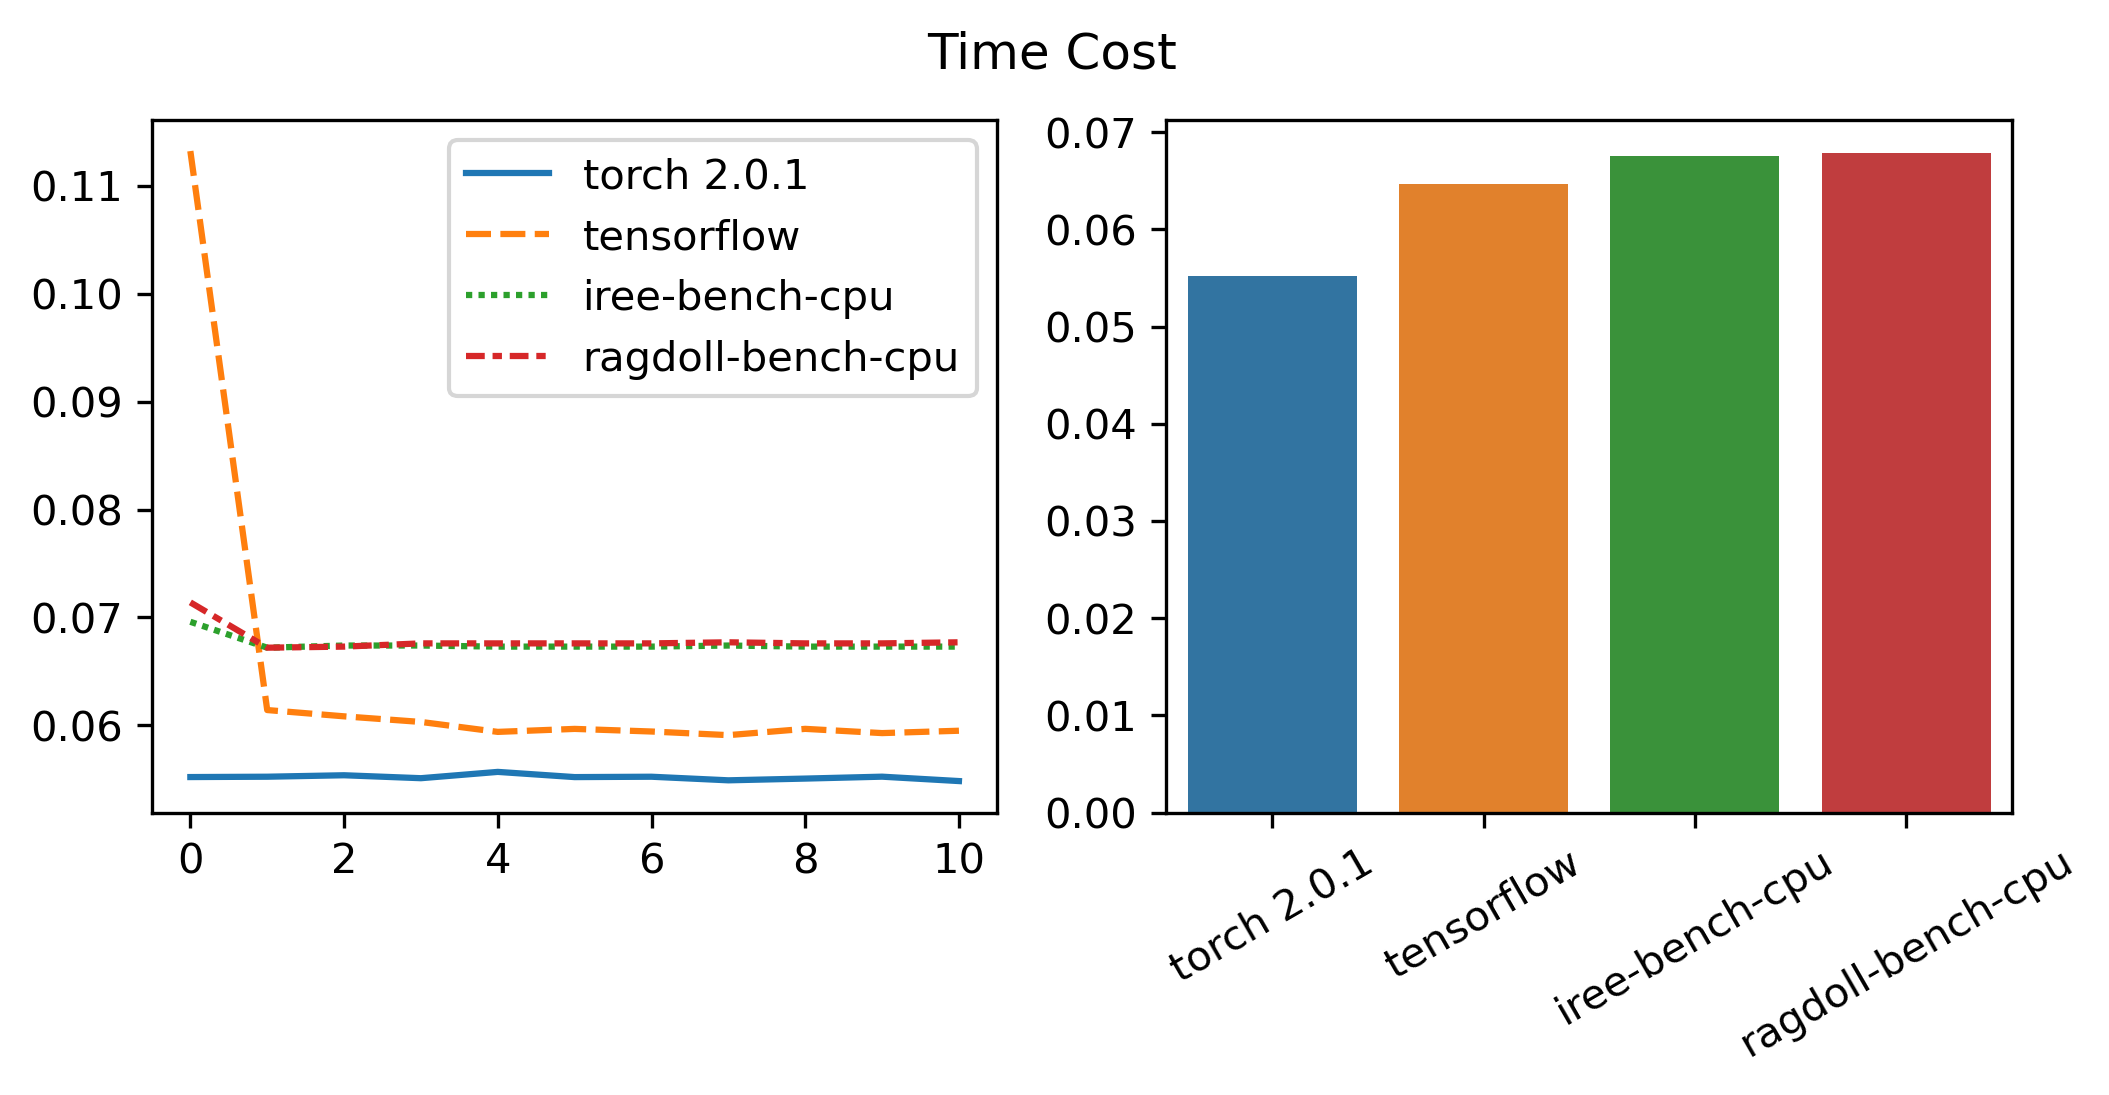

In [4]:
# to compile CPU version IREE-system kernel, just change 'cuda' to 'llvm-cpu'
#!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
#-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.bench.vmfb.cpu \
#--iree-hal-target-backends=llvm-cpu \
#--iree-hal-benchmark-dispatch-repeat-count=17 \
#--iree-llvmcpu-debug-symbols=false \
#--iree-llvmcpu-target-triple=x86_64-pc-linux-elf
#workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".bench.vmfb.cpu"
compiled_baseline = ragdoll.compile(RAGDOLL_WORKSPACE+"/"+CASE_NAME+".mlir.linalg", "cpu", "input", "codegen", benchmark=True)
print(compiled_baseline)
iree_bench = ragdoll_op_benchmark(
    compiled_baseline,
    [(1026, 2556), (2556, 1026)], 
    device='cpu',
    repetitions=17, 
    measure_count=11)
print(iree_bench)

!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
--compile-from=input \
--compile-to=executable-sources \
--iree-hal-target-backends=llvm-cpu \
--iree-opt-const-eval=1 \
--iree-opt-const-expr-hoisting=1 \
--iree-opt-numeric-precision-reduction=1 \
--iree-stream-partitioning-favor=min-peak-memory \
--iree-flow-enable-fuse-padding-into-linalg-consumer-ops \
--iree-flow-zero-fill-empty-tensors \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources.cpu
#--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
#--iree-opt-demote-f32-to-f16 \

!iree-opt {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources.cpu \
--pass-pipeline="builtin.module(hal.executable(hal.executable.variant(iree-llvmcpu-select-lowering-strategy)))" \
--iree-llvmcpu-enable-transform-dialect-jit=0 \
--iree-hal-target-backends=llvm-cpu \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf \
--iree-llvmcpu-target-cpu-features=host \
--iree-llvmcpu-enable-ukernels=all \
--iree-llvmcpu-slp-vectorization=1 \
--iree-llvmcpu-number-of-threads=48 \
--iree-llvmcpu-distribution-size=96 \
 > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations.cpu
# --iree-llvmcpu-target-cpu-features=+avx2,+fma,+avx \

# inherent repeatance compilation for benchmark
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations.cpu \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.optimised.bench.vmfb.cpu \
--compile-from=executable-configurations \
--iree-hal-target-backends=llvm-cpu \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf \
--iree-llvmcpu-target-cpu-features=host \
--iree-hal-benchmark-dispatch-repeat-count=17


# benchmark torch
torch_bench = torch_op_benchmark('matmul', 
                                 [(1026, 2556), (2556, 1026)], 
                                 device='cpu',
                                 repetitions=17, 
                                 measure_count=11)

tf_bench = tf_op_benchmark('matmul', 
                             [(1026, 2556), (2556, 1026)], 
                             device='cpu',
                             repetitions=17, 
                             measure_count=11)

workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".optimised.bench.vmfb.cpu"
ragdoll_bench = ragdoll_op_benchmark(
    workload_fb,
    [(1026, 2556), (2556, 1026)], 
    device='cpu',
    repetitions=17, 
    measure_count=11)
print(ragdoll_bench)
names = ["torch 2.0.1", "tensorflow", "iree-bench-cpu", "ragdoll-bench-cpu"]
results = [np.array(torch_bench), np.array(tf_bench), np.array(iree_bench), np.array(ragdoll_bench)]
draw_plots_nx1(["line", "bar"], [names, names], [results, results], title="Time Cost", rotation=30)